# Modelagem preditiva

Neste notebook vamos estudar a predição do sinal (alta ou baixa) do preço de uma ação (AMZN)

Faremos aqui uma modelagem categórica e utilizaremos os modelos de regressão logística e XGBoost.



#### Setup inicial

Instalação de Pacotes

In [1]:
# !pip install "yfinance==0.2.65" "pandas<2.0.0" "numpy<2.0.0" "scikit-learn==1.7.1" "xgboost==3.0.2" "matplotlib==3.10.3" "ipython==9.4.0" "jupyterlab==4.4.5" "seaborn==0.13.2"

Imports

In [2]:
import warnings


import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)
import matplotlib.pyplot as plt

Configurações iniciais

In [3]:
warnings.filterwarnings("ignore")

## Etapa 1: Baixar dados da Amazon

In [4]:
df = yf.download('AMZN', period='20y', interval='1d')
df.columns

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'AMZN'),
            (  'High', 'AMZN'),
            (   'Low', 'AMZN'),
            (  'Open', 'AMZN'),
            ('Volume', 'AMZN')],
           names=['Price', 'Ticker'])

In [5]:
df = df[['Close', "High", "Low", "Open", "Volume"]].dropna().reset_index()
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df_model = df.dropna().copy()

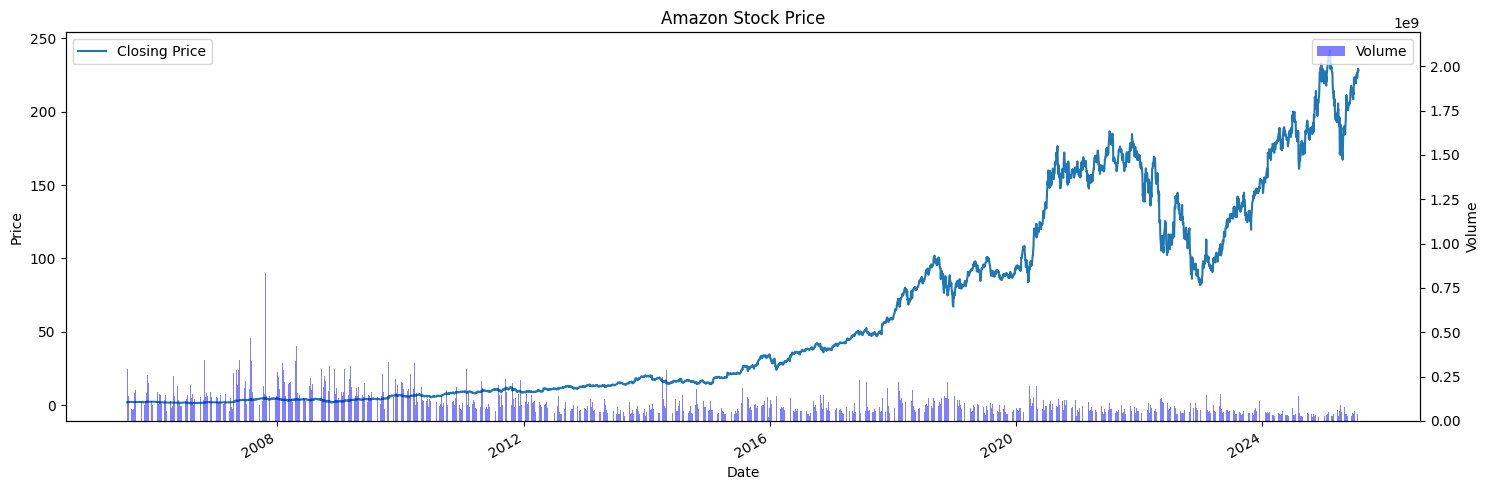

In [6]:
ax = df.plot(x='Date', y='Close', kind='line', label='Closing Price')
ax.set_title('Amazon Stock Price')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
fig = ax.get_figure()
fig.set_figwidth(15)
fig.set_figheight(5)


# add the volume as a bar chart with a secondary y-axis
ax2 = ax.twinx()
ax2.bar(df['Date'], df['Volume'], alpha=0.5, color='blue', label='Volume')
ax2.set_ylabel('Volume')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()

## Etapa 2: Criando features e target

In [7]:
dataset = pd.DataFrame()

In [8]:
dataset["Close"] = df["Close"]

delta = df['Close'].diff()
dataset["Delta"] = delta.shift(1)

threshold = 0.005  # desconsiderando variações menores que 0.5%
dataset['Target'] = np.where(
    delta > threshold, 1, np.where(delta < -threshold, 0, np.nan)
)

Podemos utilizar o retorno dos dias anteriores para prever o retorno do dia atual.

In [9]:
dataset['Return'] = dataset['Close'].pct_change().shift(1)

Podemos criar N lags de 1 a N

In [10]:
def make_lags(series: pd.Series, n_lags):
    return series.shift(n_lags)


def make_n_lags(df, n_lags, column):
    for i in range(1, n_lags + 1):
        df[f"{column}_lag{i}"] = df[column].shift(i)
    return df

In [11]:
# vamos criar N lags de 1 a N
n_lags = 10

# drop after the lags are created
dataset = make_n_lags(dataset, n_lags, 'Target')

Os dados de máxima e mínima não podem ser utilizados para prever o preço do fechamento dentro do mesmo dia, porém podemos utilizá-los para prever o preço de fechamento do dia seguinte.

In [12]:
dataset["High"] = df["High"].shift(1)
dataset["Low"] = df["Low"].shift(1)

Vamos também considerar o intervalo de variação diário do preço de fechamento.

In [13]:
dataset["Volatilidade"] = df["High"] - df["Low"]
dataset["Volatilidade_relativa"] = dataset["Volatilidade"] / dataset["Low"]

O dado de abertura é o primeiro dado de cada dia, logo podemos utilizá-lo com segurança.

In [14]:
dataset["Open"] = df["Open"]

Vamos também utilizar dados de médias móveis, para diferentes janelas de tempo.

In [15]:
# 1 semana útil = 5 dias
df['MA5'] = df['Close'].rolling(window=5).mean().shift(1)

# 1 mês útil = 22 dias
df['MA22'] = df['Close'].rolling(window=22).mean().shift(1)

# 3 meses úteis (trimestre)
df['MA66'] = df['Close'].rolling(window=66).mean().shift(1)

# 6 meses úteis (semestre)
df['MA132'] = df['Close'].rolling(window=132).mean().shift(1)

# 1 ano útil = 252 dias
df['MA252'] = df['Close'].rolling(window=252).mean().shift(1)

In [16]:
dataset.drop("Close", axis=1, inplace=True)
df_model = dataset.dropna().copy()

## Etapa 3: Separar treino e teste

In [17]:
# utilizando os últimos 30 dias como teste
train = df_model.iloc[:-30]
test = df_model.iloc[-30:]

predictors = list(train.columns)
predictors.remove('Target')

X_train, X_test = train[predictors], test[predictors]
y_train, y_test = train['Target'], test['Target']

## Etapa 4: Pipelines

In [18]:
tscv = TimeSeriesSplit(n_splits=5)

### Pipeline e GridSearch para Regressão Logística

In [19]:
pipe_lr = Pipeline(
    [('scaler', StandardScaler()), ('clf', LogisticRegression(solver='liblinear'))]
)

param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],  # regularização
    'clf__penalty': ['l1', 'l2'],  # tipo de penalização
    'clf__solver': ['liblinear'],  # necessário para suportar l1
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=tscv)
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'clf__C': [0.001, 0.01, ...], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### Pipeline e GridSearch para XGBoost

In [20]:
pipe_xgb = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier()),
    ]
)

param_grid_xgb = {
    'clf__n_estimators': [50, 100, 200],  # número de árvores
    'clf__max_depth': [3, 5, 7],  # profundidade da árvore
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.3],  # taxa de aprendizado
    'clf__subsample': [0.6, 0.8, 1.0],  # fração das amostras usadas em cada árvore
    'clf__colsample_bytree': [0.6, 0.8, 1.0],  # fração de colunas usadas por árvore
    'clf__gamma': [0, 0.1, 0.5, 1.0],  # regularização mínima para divisão
    'clf__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'clf__reg_lambda': [0.1, 1, 10],  # L2 regularization
}

grid_xgb = RandomizedSearchCV(pipe_xgb, param_grid_xgb, cv=tscv)
grid_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'clf__colsample_bytree': [0.6, 0.8, ...], 'clf__gamma': [0, 0.1, ...], 'clf__learning_rate': [0.01, 0.05, ...], 'clf__max_depth': [3, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Etapa 5: Avaliação dos modelos

In [21]:
print("Logistic Regression:")
print("Melhores parâmetros:", grid_lr.best_params_)
print("Acurácia:", accuracy_score(y_test, grid_lr.predict(X_test)))
print(classification_report(y_test, grid_lr.predict(X_test)))

Logistic Regression:
Melhores parâmetros: {'clf__C': 100, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Acurácia: 0.7
              precision    recall  f1-score   support

         0.0       0.67      0.62      0.64        13
         1.0       0.72      0.76      0.74        17

    accuracy                           0.70        30
   macro avg       0.69      0.69      0.69        30
weighted avg       0.70      0.70      0.70        30



In [22]:
print("\nXGBoost:")
print("Melhores parâmetros:", grid_xgb.best_params_)
print("Acurácia:", accuracy_score(y_test, grid_xgb.predict(X_test)))
print(classification_report(y_test, grid_xgb.predict(X_test)))


XGBoost:
Melhores parâmetros: {'clf__subsample': 1.0, 'clf__reg_lambda': 10, 'clf__reg_alpha': 0, 'clf__n_estimators': 50, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.6}
Acurácia: 0.6
              precision    recall  f1-score   support

         0.0       0.67      0.15      0.25        13
         1.0       0.59      0.94      0.73        17

    accuracy                           0.60        30
   macro avg       0.63      0.55      0.49        30
weighted avg       0.62      0.60      0.52        30



### Comparação com um modelo baseline

Vamos comparar com um modelo básico, que apenas repete a última observação

In [23]:
baseline_pred = y_test.shift(1).diff().dropna().apply(np.sign) + 1

# calculando a acurácia do baseline
baseline_accuracy = accuracy_score(y_test.loc[baseline_pred.index], baseline_pred)
print(f"Acurácia do baseline: {baseline_accuracy:.2f}")

Acurácia do baseline: 0.14


In [24]:
# acurácia dos modelos

# regressão logística
log_reg_accuracy = accuracy_score(y_test, grid_lr.predict(X_test))

# xgboost
xgb_accuracy = accuracy_score(y_test, grid_xgb.predict(X_test))

# criando a tabela de comparação
tabela_comparativa = pd.DataFrame(columns=['Modelo', 'Acurácia'])

tabela_comparativa.loc[0] = ['Baseline', f"{baseline_accuracy*100:.2f}%"]
tabela_comparativa.loc[1] = ['Logistic Regression', f"{log_reg_accuracy*100:.2f}%"]
tabela_comparativa.loc[2] = ['XGBoost', f"{xgb_accuracy*100:.2f}%"]

tabela_comparativa

,Modelo,Acurácia
0,Baseline,14.29%
1,Logistic Regression,70.00%
2,XGBoost,60.00%
